<a href="https://colab.research.google.com/github/Andalejo1109/portafolio-10k-3y/blob/main/Portafolio%20combinado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.ticker as mtick
import numpy as np


In [6]:
import numpy as np

# --- 1. Parámetros de la simulación ---
pago_mensual = 200
meses_simulacion = 36

# Definición del portafolio: Tickers y sus respectivos pesos
# Nota: Yahoo Finance usa "BRK-B" para Berkshire Hathaway Class B
tickers = ["SPYG", "SMH", "BRK-B", "VTI", "IEMG"]
pesos = np.array([0.35, 0.15, 0.25, 0.10, 0.15])

print(f"Descargando datos históricos del portafolio...")

# --- 2. Descargar datos históricos y calcular retorno combinado ---
datos = yf.download(tickers, period="5y", interval="1mo")['Close']

# Calcular los retornos mensuales por cada ETF y eliminar NAs iniciales
retornos_etfs = datos.pct_change().dropna()

# Multiplicar los retornos de cada mes por su peso y sumarlos (retorno del portafolio)
# Asegurarnos de que el orden de las columnas coincida con el array de pesos
retornos_etfs = retornos_etfs[tickers]
retornos_portafolio = (retornos_etfs * pesos).sum(axis=1)

# Nos quedamos con los últimos 36 meses
retornos_36m = retornos_portafolio.tail(meses_simulacion)

Descargando datos históricos del portafolio...


/tmp/ipykernel_3682/1004954209.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers, period="5y", interval="1mo")['Close']
[*********************100%***********************]  5 of 5 completed


In [8]:
# --- 3. Simulación del Portafolio ---
fechas = retornos_36m.index
aportes_totales = []
valores_portafolio = []

valor_actual = 0
aporte_acumulado = 0

for retorno in retornos_36m:
    aporte_acumulado += pago_mensual
    valor_actual = (valor_actual + pago_mensual) * (1 + float(retorno))

    aportes_totales.append(aporte_acumulado)
    valores_portafolio.append(valor_actual)



Generando animación del portafolio combinado...
¡Listo! Archivo guardado como 'simulacion_portafolio_combinado.gif'


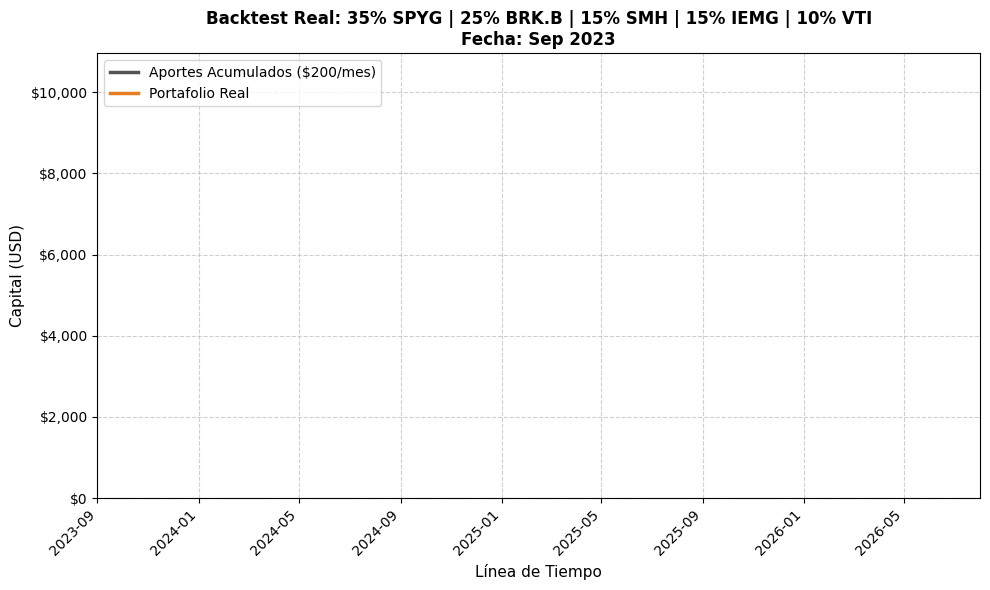

In [10]:
# --- 4. Configuración del Gráfico Animado ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.set_xlim(fechas[0], fechas[-1])
limite_y = max(valores_portafolio) * 1.05
ax.set_ylim(0, limite_y)

fmt = '${x:,.0f}'
tick = mtick.StrMethodFormatter(fmt)
ax.yaxis.set_major_formatter(tick)

def update(frame):
    ax.clear()

    ax.set_xlim(fechas[0], fechas[-1])
    ax.set_ylim(0, limite_y)
    ax.yaxis.set_major_formatter(tick)

    fechas_frame = fechas[:frame+1]
    aportes_frame = aportes_totales[:frame+1]
    valores_frame = valores_portafolio[:frame+1]

    ax.plot(fechas_frame, aportes_frame, color='#555555', linewidth=2.5,
    label=f'Aportes Acumulados (${pago_mensual}/mes)')
    # Color distintivo para el portafolio combinado
    ax.plot(fechas_frame, valores_frame, color='#e67e22', linewidth=2.5,
    label=f'Portafolio Real')

    fecha_actual = fechas_frame[-1].strftime('%b %Y')
    ax.set_title(f"Backtest Real: 35% SPYG | 25% BRK.B | 15% SMH | 15% IEMG | 10% VTI\nFecha: {fecha_actual}",
    fontsize=12, fontweight='bold')

    ax.set_xlabel("Línea de Tiempo", fontsize=11)
    ax.set_ylabel("Capital (USD)", fontsize=11)

    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper left', fontsize=10)

    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()

# --- 5. Renderizar y Guardar ---
print("Generando animación del portafolio combinado...")

ani = FuncAnimation(fig, update, frames=len(fechas), interval=150, repeat=False)
nombre_archivo = "simulacion_portafolio_combinado.gif"
ani.save(nombre_archivo, writer=PillowWriter(fps=8))

print(f"¡Listo! Archivo guardado como '{nombre_archivo}'")

¡Listo! Gráfico guardado como 'grafica_estatica_35%_SPYG__15%_SMH__25%_BRK-B__10%_VTI__15%_IEMG.png' en tu carpeta actual.


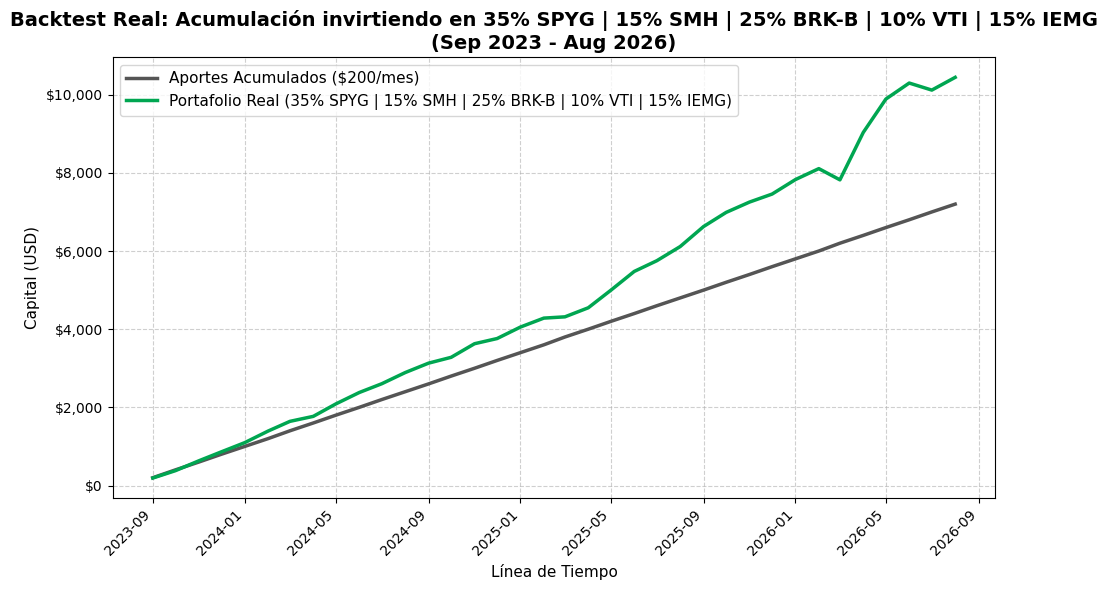

In [13]:
# --- 6. Configuración y Generación del Gráfico Estático ---
fig, ax = plt.subplots(figsize=(10, 6))

# Construct the portfolio display name
portfolio_display_name_parts = []
for i in range(len(tickers)):
    portfolio_display_name_parts.append(f"{int(pesos[i]*100)}% {tickers[i]}")
portfolio_display_name = " | ".join(portfolio_display_name_parts)

# Trazar las dos líneas
ax.plot(fechas, aportes_totales, color='#555555', linewidth=2.5,
label=f'Aportes Acumulados (${pago_mensual}/mes)')
ax.plot(fechas, valores_portafolio, color='#00a651', linewidth=2.5,
label=f'Portafolio Real ({portfolio_display_name})')

# Formatear el eje Y como dólares ($X,XXX)
fmt = '${x:,.0f}'
tick = mtick.StrMethodFormatter(fmt)
ax.yaxis.set_major_formatter(tick)

# Títulos
fecha_inicial = fechas[0].strftime('%b %Y')
fecha_final = fechas[-1].strftime('%b %Y')
ax.set_title(f"Backtest Real: Acumulación invirtiendo en {portfolio_display_name}\n({fecha_inicial} - {fecha_final})",
fontsize=14, fontweight='bold')
ax.set_xlabel("Línea de Tiempo", fontsize=11)
ax.set_ylabel("Capital (USD)", fontsize=11)

# Estética adicional
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left', fontsize=11)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()

# --- 7. Guardar la imagen ---
nombre_imagen = f"grafica_estatica_{portfolio_display_name.replace(' ', '_').replace('|', '')}.png"
plt.savefig(nombre_imagen, dpi=300) # dpi=300 asegura calidad de impresión/HD
print(f"¡Listo! Gráfico guardado como '{nombre_imagen}' en tu carpeta actual.")